In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"raghav290612","key":"06b7e53c24726691018e1da1d3b34226"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:21<00:00, 17.0MB/s]



In [5]:
!unzip -q intel-image-classification.zip

In [6]:
!ls

intel-image-classification.zip	sample_data  seg_test
kaggle.json			seg_pred     seg_train


In [7]:
import tensorflow as tf
from tensorflow.keras import layers
train_path = "/content/seg_train/seg_train"
test_path = "/content/seg_test/seg_test"
train = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=32)
test = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32)

class_names = train.class_names
print("Classes:", class_names)

base = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet")

base.trainable = False

model = tf.keras.Sequential([
    layers.Rescaling(1./255),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(6, activation="softmax")])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
model.fit(train, epochs=5)
model.evaluate(test)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.8717 - loss: 0.3511
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9138 - loss: 0.2357
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9231 - loss: 0.2115
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9294 - loss: 0.1941
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9327 - loss: 0.1804
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.9177 - loss: 0.2281


[0.2280854731798172, 0.9176666736602783]

In [8]:
from google.colab import files
uploaded = files.upload()

Saving test11.jpg to test11.jpg


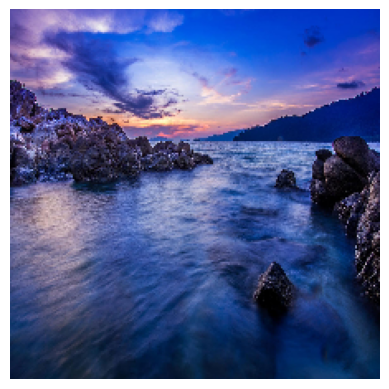

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Predicted Class: sea


In [9]:
import numpy as np
import matplotlib.pyplot as plt

img_path = "test11.jpg"

img = tf.keras.utils.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)